## Импортируем нужные библиотеки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

warnings.filterwarnings('ignore')

Загружаем и распаковываем наш датасет и отобразим первые 5 строк, чтобы визуально оценить с чем будем работать


In [ ]:
!wget https://storage.yandexcloud.net/exel1/archive.zip
!unzip archive.zip

--2025-12-26 14:18:43--  https://storage.yandexcloud.net/exel1/archive.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 768769 (751K) [application/x-zip-compressed]
Saving to: ‘archive.zip’

archive.zip         100%[===================>] 750.75K   790KB/s    in 0.9s    

2025-12-26 14:18:45 (790 KB/s) - ‘archive.zip’ saved [768769/768769]

Archive:  archive.zip
  inflating: loan_data.csv           


In [ ]:
df = pd.read_csv("loan_data.csv")

In [ ]:
print("Отобразим первые 5 строк датасета:")
display(df.head())

Отобразим первые 5 строк датасета:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Выводим тип данных, проверям на пропуски, дубликаты

In [ ]:
print("\nИнфо о данных (типы и количество):")
print(df.info())


Инфо о данных (типы и количество):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 

In [ ]:
# Проверка на пропуски
print("\nПропуски в столбцах:")
print(df.isnull().sum())


Пропуски в столбцах:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [ ]:
# Напишем условием для удаления, если пропуски все же бы были
if df.isnull().sum().sum() > 0:
    df = df.dropna() # Удаление строк с пропусками

In [ ]:
# Проверка датасета на дубликаты
duplicates = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"После удаления дубликатов осталось строк: {len(df)}")

print(f"\nИтоговый размер очищенного датасета: {df.shape}")


Количество дубликатов: 0

Итоговый размер очищенного датасета: (45000, 14)


# Проведем визуализацию данных для наглядности


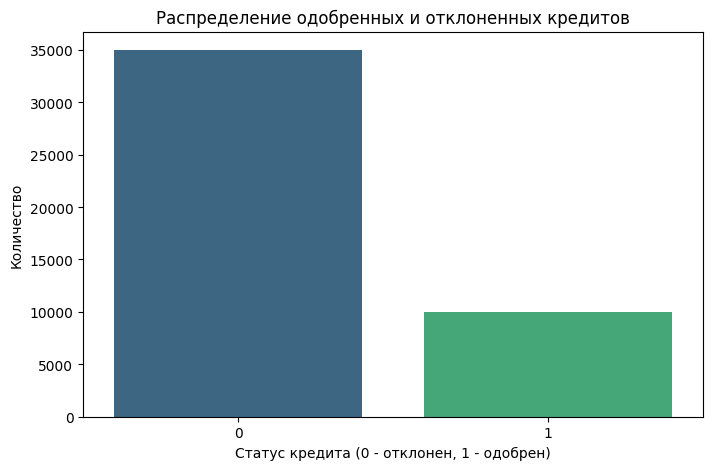

In [ ]:
# Визуализация классов (одобренных и отклоненных кредитов)
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Распределение одобренных и отклоненных кредитов')
plt.xlabel('Статус кредита (0 - отклонен, 1 - одобрен)')
plt.ylabel('Количество')
plt.show()

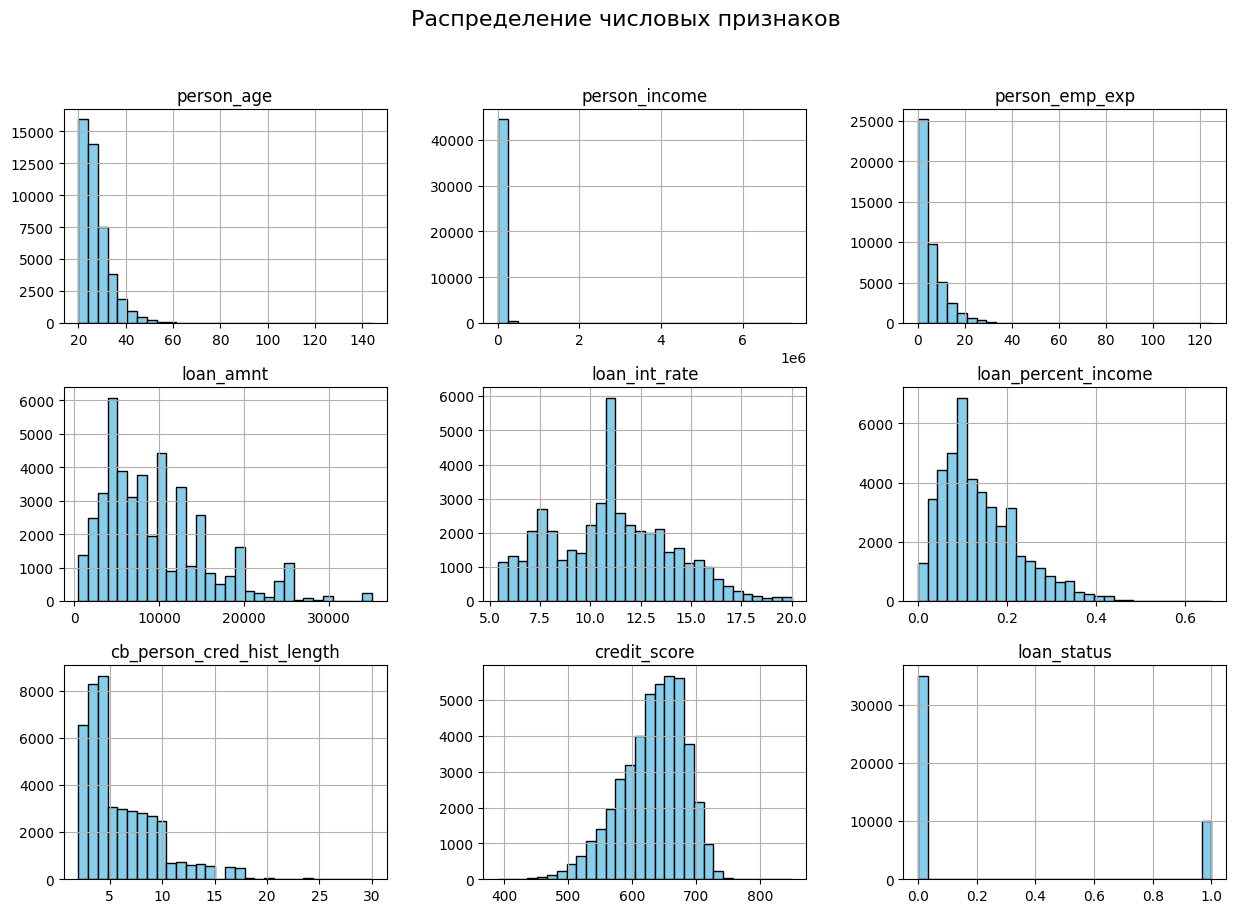

In [ ]:
# Анализ числовых признаков
# Выберем несколько ключевых числовых столбцов для анализа распределений
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols].hist(figsize=(15, 10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.show()

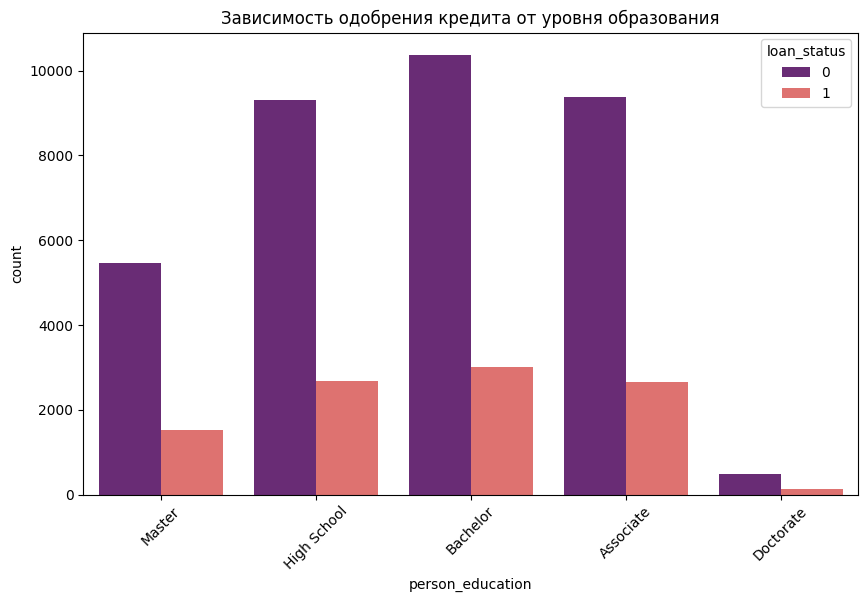

In [ ]:
# Анализ категориальных признаков (взаимосвязь с целевой переменной)
# Посмотрим, как образование влияет на статус кредита
# Как видим из графика, образование не имеет существенного влияния на одобрение кредита
plt.figure(figsize=(10, 6))
sns.countplot(x='person_education', hue='loan_status', data=df, palette='magma')
plt.title('Зависимость одобрения кредита от уровня образования')
plt.xticks(rotation=45)
plt.show()

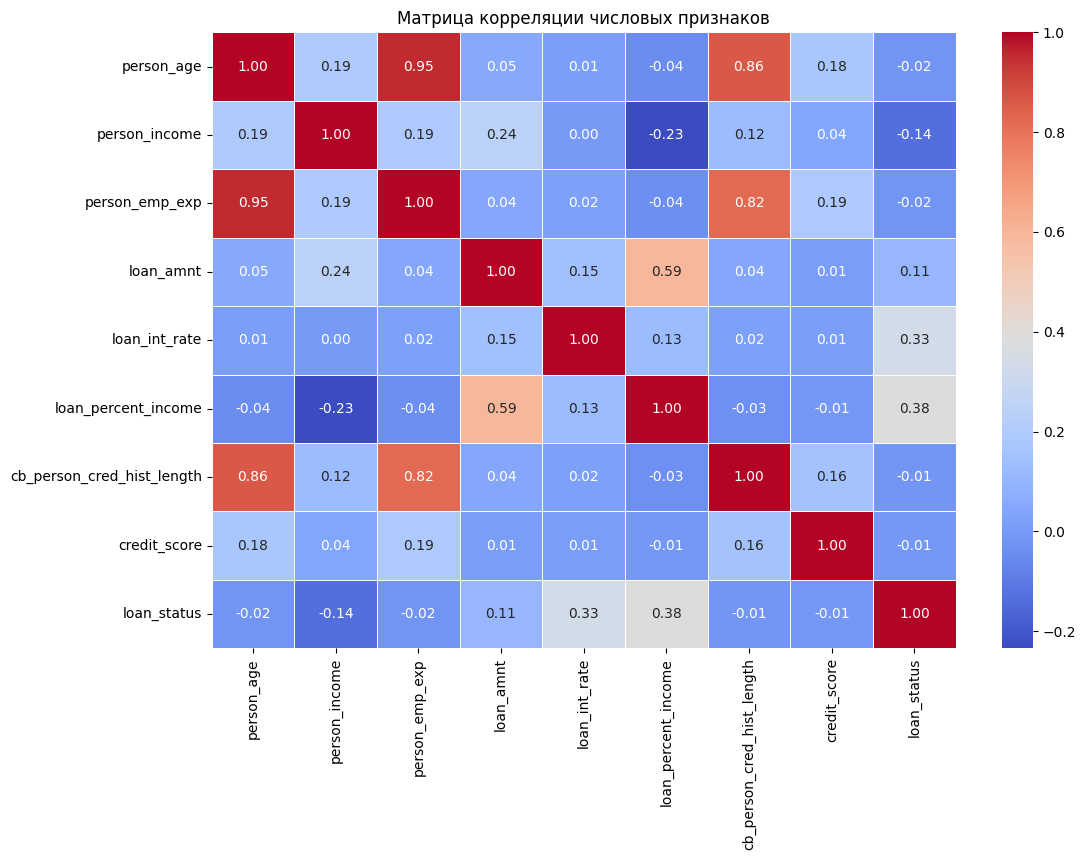

In [ ]:
# Матрица корреляции
plt.figure(figsize=(12, 8))
# Для корреляции берем только числовые столбцы
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

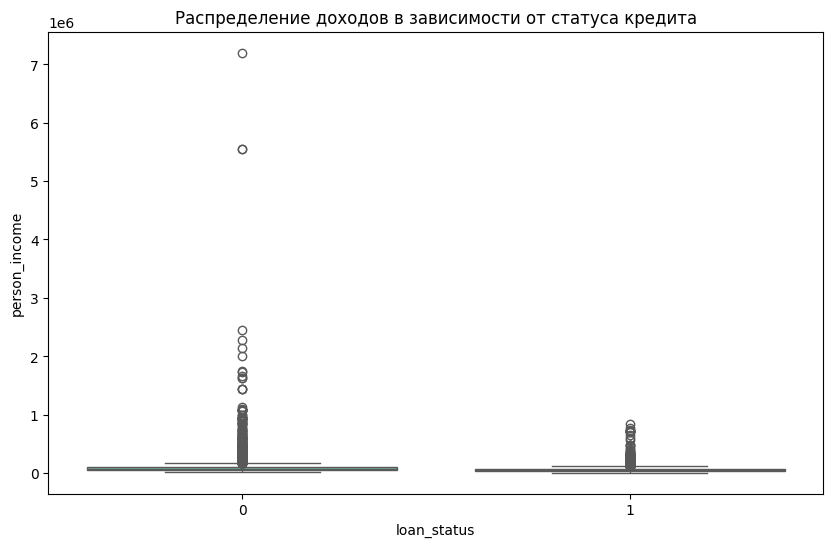

In [ ]:
# Boxplot (Ящик с усами) для поиска выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')
plt.title('Распределение доходов в зависимости от статуса кредита')
plt.show()

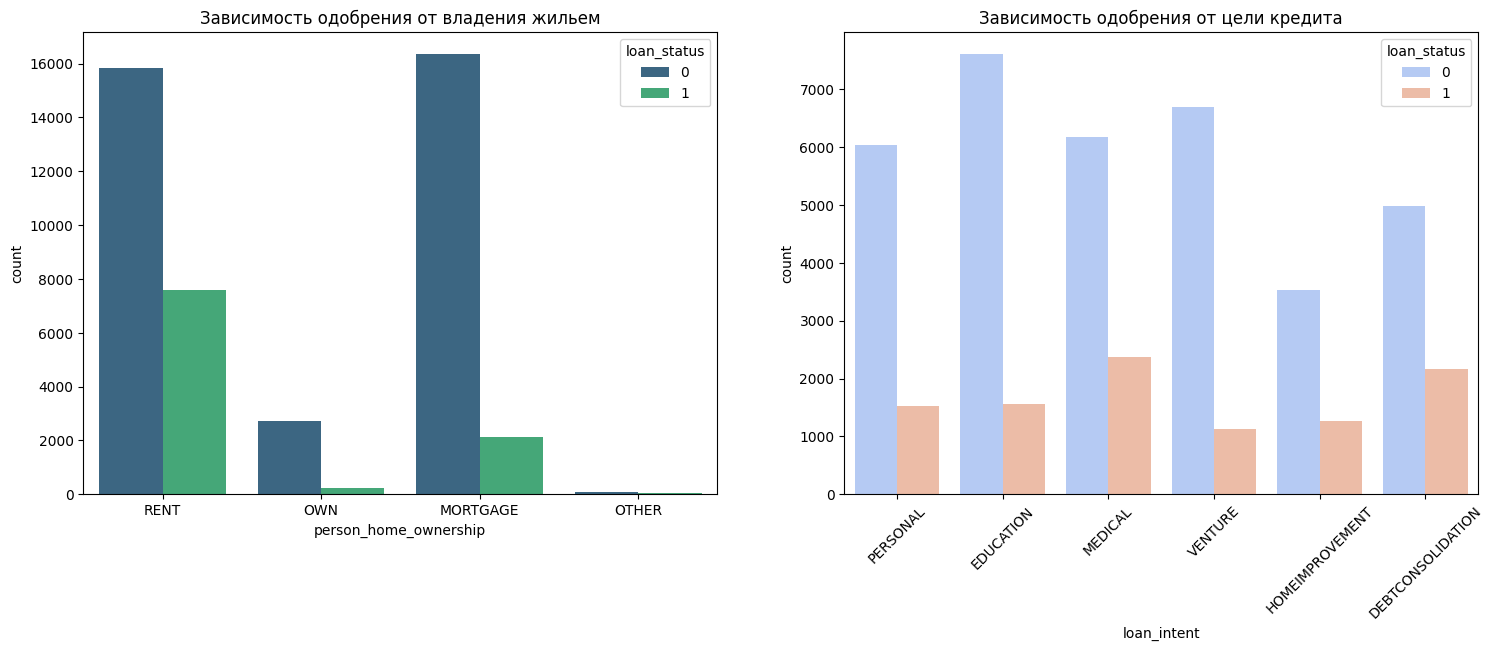

In [ ]:
# Создадим сетку графиков для оставшихся важных категорий
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Влияние типа жилья
sns.countplot(x='person_home_ownership', hue='loan_status', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Зависимость одобрения от владения жильем')
# Влияние цели кредита
sns.countplot(x='loan_intent', hue='loan_status', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Зависимость одобрения от цели кредита')
plt.xticks(rotation=45)
plt.show()

Далее мы задаем в переменной **y** целевой признак а в **X** удаляем ее, для того, чтобы модель могла предсказать ее

In [ ]:
y = df['loan_status']
X = df.drop('loan_status', axis=1)

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numerical_cols)



Категориальные признаки: Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')
Числовые признаки: Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')


Разделяем данные на две части: обучающую (80%) и тестовую (20%).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

С помощью **ColumnTransformer** настраиваем автоматическую обработку признаков:
Числовые данные масштабируем (**StandardScaler**), приводя их к единому распределению.
Категориальные данные преобразуем в числовой вид с помощью прямого кодирования (**OneHotEncoder**).

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)


Инициализируем и обучаем несколько различных моделей машинного обучения в цикле. Для каждой модели рассчитываем метрику точности (**Accuracy**) на обучающей и тестовой выборках, чтобы сравнить их эффективность.

In [ ]:
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=500, random_state=42)
}


--- Модель: Gradient Boosting ---
Точность на обучении: 0.9273
Точность на тесте: 0.9220


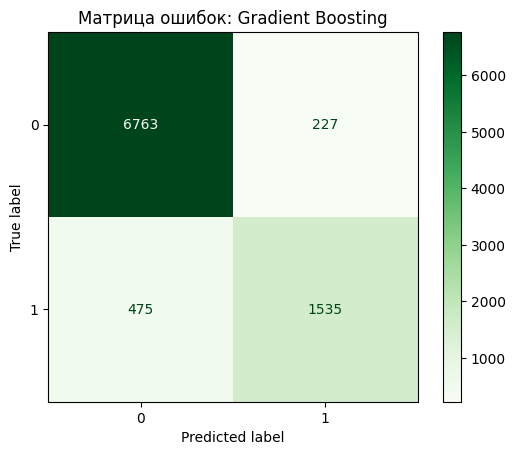



--- Модель: Random Forest ---
Точность на обучении: 1.0000
Точность на тесте: 0.9291


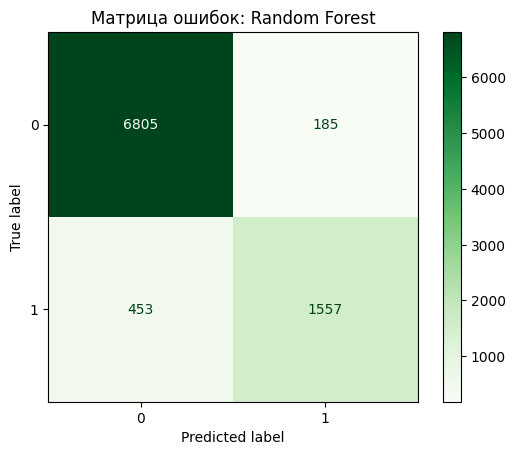



--- Модель: SVC ---
Точность на обучении: 0.9235
Точность на тесте: 0.9163


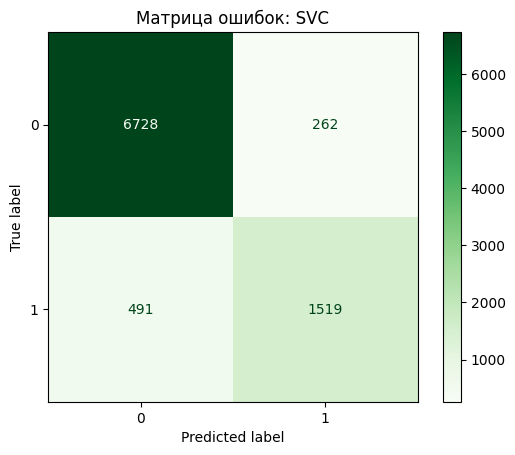



--- Модель: Neural Network (MLP) ---
Точность на обучении: 0.9397
Точность на тесте: 0.9161


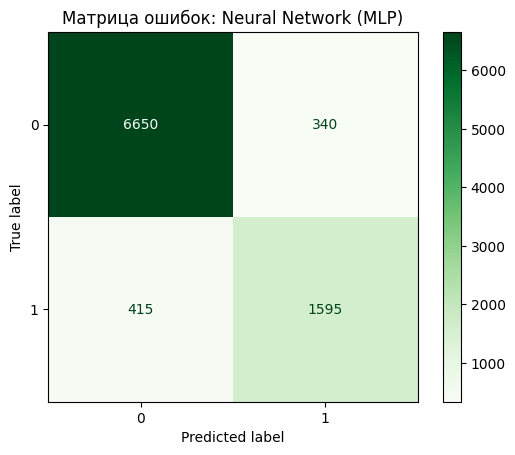



ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ:


,Model,Train Accuracy,Test Accuracy
0,Gradient Boosting,0.927306,0.922000
1,Random Forest,1.000000,0.929111
2,SVC,0.923472,0.916333
3,Neural Network (MLP),0.939694,0.916111


In [ ]:
# Создаем пустой список для итоговой таблицы сравнения
comparison_data = []

for name, model in models.items():
    print(f"--- Модель: {name} ---")
    model.fit(X_train_transformed, y_train)
    train_acc = model.score(X_train_transformed, y_train)
    test_acc = model.score(X_test_transformed, y_test)
    comparison_data.append({"Model": name, "Train Accuracy": train_acc, "Test Accuracy": test_acc})

    print(f"Точность на обучении: {train_acc:.4f}")
    print(f"Точность на тесте: {test_acc:.4f}")

    y_pred = model.predict(X_test_transformed)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Greens')
    plt.title(f"Матрица ошибок: {name}")
    plt.show()
    print("\n")

results_df = pd.DataFrame(comparison_data)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ:")
display(results_df)

Для каждой модели строим **Confusion Matrix** и в конце вывели сводную таблицу всех обученных моделей для нагядного сравнения. Осталось только сохранить понравившуюся нам модель с помощью. Далее мы создаем итоговый пайплайн (конвейер), объединяющий предобработку и лучшую модель. Обучаем его на полных данных и сохраняем готовую модель в файл **loan_approval_model.pkl** для дальнейшего использования. Например развернуть модель через **Streamlit**, чем мы и займемся, но уже в Vs Code.

In [ ]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

final_model.fit(X_train, y_train)

joblib.dump(final_model, 'loan_approval_model.pkl')


['loan_approval_model.pkl']